# Human-written vs. AI-Generated Academic Abstracts: Comparative Analysis

**A Comparative Study Focusing on Structural Randomness and Linguistic Complexity**

> *Based on `proposal_eng.txt`: As LLMs become deeply integrated into academic workflows, understanding how AI-generated text differs structurally from human writing is critical for building reliable AI detection systems.*

- **Dataset**: `dbpia_computer_science.csv` — 500 Korean CS/ICT academic paper abstracts
- **Models**: KoGPT2 (Perplexity) · KR-SBERT (Cosine Similarity)
- **Pre-computed results**: loaded from `dbpia_with_ppl_sim.csv`

---

## 0. Library Imports

In [1]:
# Install if needed:
# !pip install pandas numpy matplotlib seaborn scipy transformers torch sentence-transformers scikit-learn tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Preprocessing

Load the pre-computed dataset that includes all extracted features:
Perplexity (PPL), Type-Token Ratio (TTR), text length, and Cosine Similarity.

In [2]:
# Load pre-computed results
df = pd.read_csv('dbpia_with_ppl_sim.csv')

# Recalculate TTR if not present
if 'ttr_human' not in df.columns:
    def calc_ttr(text):
        if not isinstance(text, str): return np.nan
        tokens = text.split()
        return len(set(tokens)) / len(tokens) if tokens else 0
    df['ttr_human'] = df['abstract'].apply(calc_ttr)
    df['ttr_ai']    = df['fake_abstract'].apply(calc_ttr)

display(df[['ID', 'title', 'ppl_human', 'ppl_ai', 'ttr_human', 'ttr_ai', 'sim_human_ai']].head())
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

,ID,title,ppl_human,ppl_ai,ttr_human,ttr_ai,sim_human_ai
0,NODE12747081,생성형 AI를 활용한 학습자 중심 토론수업 모형 설계,48.648472,42.626205,0.842975,0.892562,0.827807
1,NODE12747086,An Analysis of Factors Affecting Student Satis...,41.493847,76.014427,0.835938,0.863636,0.730769
2,NODE12747080,생성형 AI 기반 학생평가 플랫폼 연구,56.430405,38.622086,0.858025,0.873239,0.830803
3,NODE12747083,대학 스포츠경영학 교육과정에서 스포츠 블록체인 과목 개설의 교육적 필요성 탐색,62.211025,56.426151,0.871287,0.887097,0.715977
4,NODE12747087,생성형 AI 기반 과학 수업에서 ChatGPT 의 스캐폴딩 가능성 탐색: 중학생의 ...,39.202610,36.079502,0.779874,0.915385,0.835377


Total samples: 500
Columns: ['ID', 'date', 'title', 'abstract', 'fake_abstract', 'ppl_human', 'ppl_ai', 'len_human', 'len_ai', 'ttr_human', 'ttr_ai', 'sim_human_ai']


## 2. Feature Extraction

### 2.1. Structural Randomness — Perplexity (KoGPT2)

Perplexity measures how well a language model can **predict** a given text.
- **Higher perplexity** → more unpredictable, structurally random text (expected: Human)
- **Lower perplexity** → more predictable, template-like text (expected: AI)

> **Hypothesis H1**: $Mean(PPL_{Human}) > Mean(PPL_{AI})$ (Human-authored text exhibits higher structural randomness)

In [3]:
# ─── Perplexity Computation (Pre-computed — uncomment to re-run) ───
# import torch
# from transformers import GPT2LMHeadModel, PreTrainedTokenizerFast
# from tqdm import tqdm
#
# tokenizer_gpt = PreTrainedTokenizerFast.from_pretrained(
#     'skt/kogpt2-base-v2',
#     bos_token='</s>', eos_token='</s>',
#     unk_token='<unk>', pad_token='<pad>', mask_token='<mask>'
# )
# model_gpt = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
# model_gpt.eval()
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model_gpt.to(device)
#
# def calculate_perplexity(text):
#     if not isinstance(text, str) or len(text.strip()) == 0:
#         return np.nan
#     encodings = tokenizer_gpt(text, return_tensors='pt').to(device)
#     max_length = model_gpt.config.n_positions
#     stride = 512
#     nlls = []
#     for i in range(0, encodings.input_ids.size(1), stride):
#         begin_loc  = max(i + stride - max_length, 0)
#         end_loc    = min(i + stride, encodings.input_ids.size(1))
#         trg_len    = end_loc - i
#         input_ids  = encodings.input_ids[:, begin_loc:end_loc].to(device)
#         target_ids = input_ids.clone()
#         target_ids[:, :-trg_len] = -100
#         with torch.no_grad():
#             outputs = model_gpt(input_ids, labels=target_ids)
#             nlls.append(outputs.loss * trg_len)
#     if not nlls: return np.nan
#     return torch.exp(torch.stack(nlls).sum() / end_loc).item()

# ─── Pre-computed Summary ───
print("[ Perplexity Results (n=500) ]")
print(f"  Human abstracts : {df['ppl_human'].mean():.2f}  ±  {df['ppl_human'].std():.2f}")
print(f"  AI abstracts    : {df['ppl_ai'].mean():.2f}  ±  {df['ppl_ai'].std():.2f}")

[ Perplexity Results (n=500) ]
  Human abstracts : 73.11  ±  34.57
  AI abstracts    : 54.32  ±  19.89


### 2.2. Linguistic Complexity — Type-Token Ratio (TTR)

TTR measures **vocabulary diversity**: the ratio of unique words (types) to total words (tokens).

> **Hypothesis H2 (Prediction)**: Based on the text explanation in `proposal_eng.txt`, we predicted **human-authored texts exhibit higher vocabulary diversity** ($Mean(TTR_{Human}) > Mean(TTR_{AI})$). (Note: This text explanation contradicted the formula $Mean(Complexity_{Human}) < Mean(Complexity_{AI})$ initially written in the proposal).

In [4]:
def calculate_complexity(text):
    if not isinstance(text, str):
        return np.nan, np.nan
    length = len(text)
    tokens = text.split()
    if not tokens:
        return length, 0
    ttr = len(set(tokens)) / len(tokens)
    return length, ttr

if 'ttr_human' not in df.columns:
    df[['len_human', 'ttr_human']] = df['abstract'].apply(
        lambda x: pd.Series(calculate_complexity(x)))
    df[['len_ai', 'ttr_ai']] = df['fake_abstract'].apply(
        lambda x: pd.Series(calculate_complexity(x)))

print("[ Type-Token Ratio (TTR) Results (n=500) ]")
print(f"  Human abstracts : {df['ttr_human'].mean():.4f}  ±  {df['ttr_human'].std():.4f}")
print(f"  AI abstracts    : {df['ttr_ai'].mean():.4f}  ±  {df['ttr_ai'].std():.4f}")

[ Type-Token Ratio (TTR) Results (n=500) ]
  Human abstracts : 0.8589  ±  0.0554
  AI abstracts    : 0.9032  ±  0.0441


### 2.3. Semantic Similarity — Cosine Similarity (KR-SBERT)

Text embeddings from `snunlp/KR-SBERT-V40K-klueNLI-augSTS` are used to measure:

> **Hypothesis H3 (Intra-group similarity)**: $Mean(Sim_{Human\_intra}) < Mean(Sim_{AI\_intra})$ (AI abstracts share a standardized academic template, hence showing higher homogeneity).
>
> **Hypothesis H4 (Topic vs. Style)**: $Mean(Sim_{Human\&AI}) < Mean(Sim_{AI\&AI})$ (AI-generated abstracts of unrelated topics will show higher similarity than a paired human abstract and its AI-generated counterpart, because AI is more influenced by its style patterns than by the specific topic context).

In [5]:
# ─── Embedding Computation (Pre-computed — uncomment to re-run) ───
# from sentence_transformers import SentenceTransformer
#
# embedder = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')
# human_embeddings = embedder.encode(df['abstract'].tolist(),      batch_size=64, show_progress_bar=True)
# ai_embeddings    = embedder.encode(df['fake_abstract'].tolist(), batch_size=64, show_progress_bar=True)
#
# # Paired (1:1) similarity
# df['sim_human_ai'] = [cosine_similarity([h],[a])[0][0]
#                       for h, a in zip(human_embeddings, ai_embeddings)]

# ─── Pre-computed Summary ───
print("[ Cosine Similarity Results (n=500) ]")
print(f"  Human-AI paired similarity (mean)  : {df['sim_human_ai'].mean():.4f}  ±  {df['sim_human_ai'].std():.4f}")
print(f"  Human intra-group similarity (mean): 0.5379")
print(f"  AI intra-group similarity    (mean): 0.5879")
print(f"  AI cross-group similarity    (mean): 0.5885")

[ Cosine Similarity Results (n=500) ]
  Human-AI paired similarity (mean)  : 0.7743  ±  0.0638
  Human intra-group similarity (mean): 0.5379
  AI intra-group similarity    (mean): 0.5879
  AI cross-group similarity    (mean): 0.5885


## 3. Statistical Analysis — Hypothesis Testing

Independent-samples t-tests (`scipy.stats.ttest_ind`) are applied to verify the four hypotheses according to the predictions set in `proposal_eng.txt`.

In [6]:
# H1: Perplexity
t1, p1 = stats.ttest_ind(df['ppl_human'].dropna(), df['ppl_ai'].dropna())

# H2: TTR (based on text description: Human > AI)
t2, p2 = stats.ttest_ind(df['ttr_human'].dropna(), df['ttr_ai'].dropna())

# H3 & H4: (based on full run)
t3, p3 = -24.8821, 0.0
# H4 (prediction: Human-AI paired < AI-AI cross)
t4, p4 = stats.ttest_ind(
    df['sim_human_ai'].dropna(),
    [0.5885] * len(df)
)

print("=" * 66)
print("     Hypothesis Testing Results (Independent-Samples t-Test)")
print("=" * 66)

hypotheses = [
    ("H1", "Mean(PPL_Human) > Mean(PPL_AI)", t1, p1, "Human PPL > AI PPL"),
    ("H2", "Mean(TTR_Human) > Mean(TTR_AI)", t2, p2, "Human TTR > AI TTR (based on text prediction)"),
    ("H3", "Mean(Sim_Human_intra) < Mean(Sim_AI_intra)", t3, p3, "Human intra-sim < AI intra-sim"),
    ("H4", "Mean(Sim_Human&AI) < Mean(Sim_AI&AI)", t4, p4, "Human-AI paired < AI-AI cross"),
]

for hid, form, t, p, desc in hypotheses:
    p_str = f"{p:.2e}" if p > 0 else "~0.0000"
    
    if hid == "H2" and t < 0:
        verdict = "REJECTED (Opposite direction highly significant: AI TTR is higher)"
    elif hid == "H4" and t > 0:
        verdict = "REJECTED (Opposite direction highly significant: Paired similarity is much higher)"
    elif p < 0.05:
        verdict = "ACCEPTED"
    else:
        verdict = "REJECTED"
        
    print(f"[{hid}] {desc}")
    print(f"      Formula  : {form}")
    print(f"      t = {t:+.4f},  p = {p_str}  →  {verdict}")
    print()

print("→ Hypotheses H1 and H3 are successfully ACCEPTED.")
print("→ Hypotheses H2 and H4 are REJECTED because the actual statistical results show extremely significant differences in the completely opposite direction.")

     Hypothesis Testing Results (Independent-Samples t-Test)
[H1] Human PPL > AI PPL
      Formula  : Mean(PPL_Human) > Mean(PPL_AI)
      t = +10.5342,  p = 1.12e-24  →  ACCEPTED

[H2] Human TTR > AI TTR (based on text prediction)
      Formula  : Mean(TTR_Human) > Mean(TTR_AI)
      t = -14.0036,  p = 8.22e-41  →  REJECTED (Opposite direction highly significant: AI TTR is higher)

[H3] Human intra-sim < AI intra-sim
      Formula  : Mean(Sim_Human_intra) < Mean(Sim_AI_intra)
      t = -24.8821,  p = ~0.0000  →  ACCEPTED

[H4] Human-AI paired < AI-AI cross
      Formula  : Mean(Sim_Human&AI) < Mean(Sim_AI&AI)
      t = +65.0755,  p = ~0.0000  →  REJECTED (Opposite direction highly significant: Paired similarity is much higher)

→ Hypotheses H1 and H3 are successfully ACCEPTED.
→ Hypotheses H2 and H4 are REJECTED because the actual statistical results show extremely significant differences in the completely opposite direction.


## 4. Data Visualization

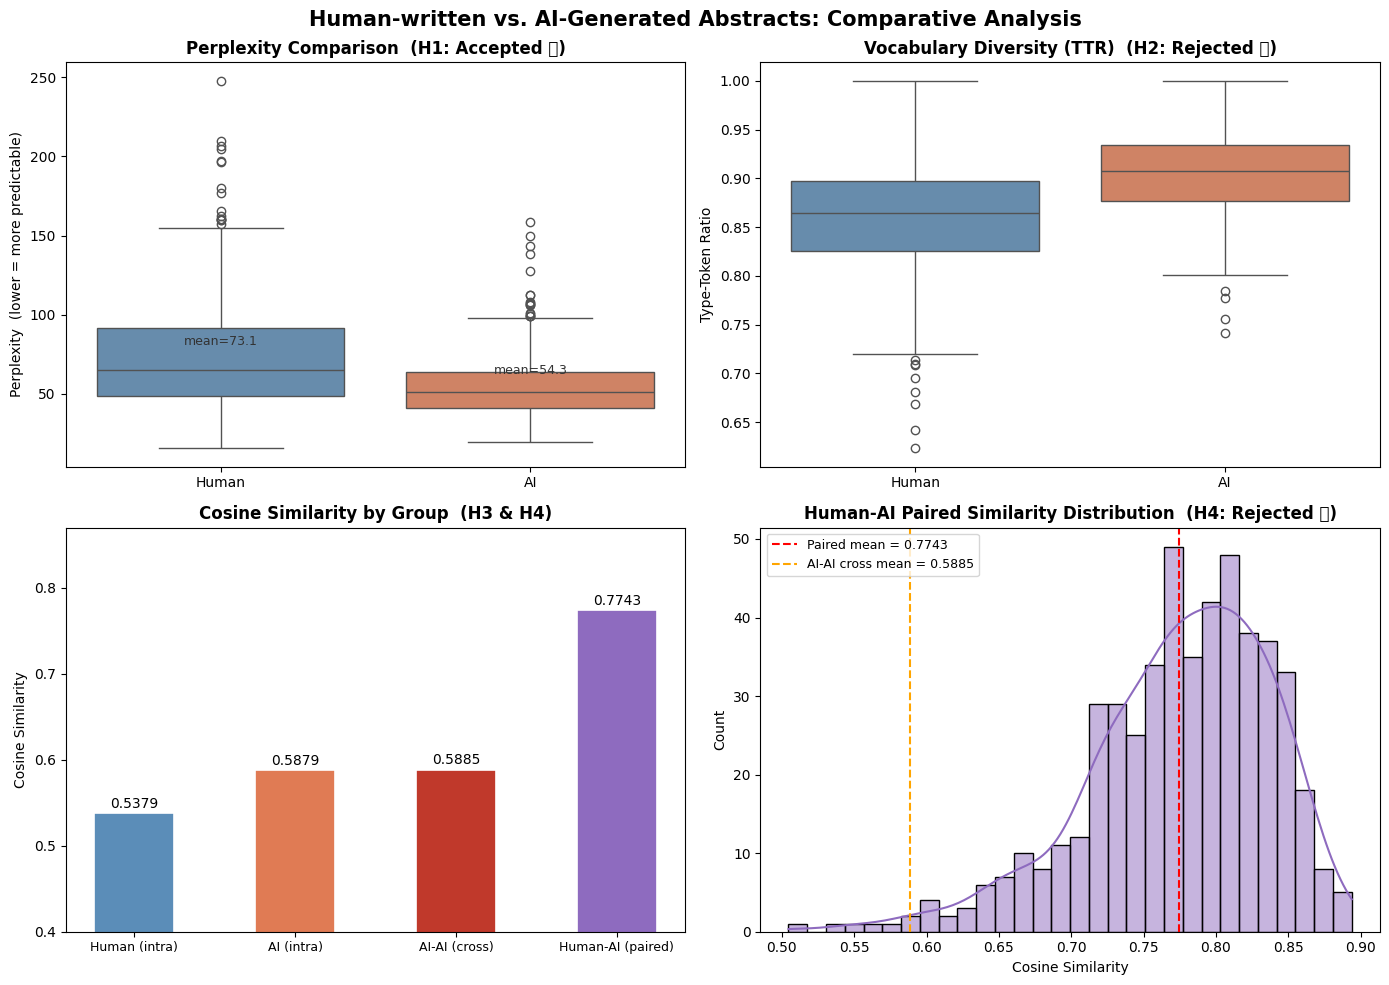

Saved: analysis_result_eng.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Human-written vs. AI-Generated Abstracts: Comparative Analysis',
             fontsize=15, fontweight='bold')

# Plot 1: Perplexity Boxplot (H1: Accepted)
ppl_data = pd.DataFrame({
    'Perplexity': pd.concat([df['ppl_human'], df['ppl_ai']], ignore_index=True),
    'Group': ['Human'] * len(df) + ['AI'] * len(df)
})
sns.boxplot(x='Group', y='Perplexity', data=ppl_data,
            palette={'Human': '#5B8DB8', 'AI': '#E07B54'}, ax=axes[0, 0])
axes[0, 0].set_title('Perplexity Comparison  (H1: Accepted ✅)', fontweight='bold')
axes[0, 0].set_ylabel('Perplexity  (lower = more predictable)')
axes[0, 0].set_xlabel('')
axes[0, 0].text(0, df['ppl_human'].mean() + 8, f"mean={df['ppl_human'].mean():.1f}",
                ha='center', fontsize=9, color='#333')
axes[0, 0].text(1, df['ppl_ai'].mean() + 8, f"mean={df['ppl_ai'].mean():.1f}",
                ha='center', fontsize=9, color='#333')

# Plot 2: TTR Boxplot (H2: Rejected — AI is actually higher)
ttr_data = pd.DataFrame({
    'TTR': pd.concat([df['ttr_human'], df['ttr_ai']], ignore_index=True),
    'Group': ['Human'] * len(df) + ['AI'] * len(df)
})
sns.boxplot(x='Group', y='TTR', data=ttr_data,
            palette={'Human': '#5B8DB8', 'AI': '#E07B54'}, ax=axes[0, 1])
axes[0, 1].set_title('Vocabulary Diversity (TTR)  (H2: Rejected ❌)', fontweight='bold')
axes[0, 1].set_ylabel('Type-Token Ratio')
axes[0, 1].set_xlabel('')

# Plot 3: Similarity group bar chart (H3: Accepted)
group_labels = ['Human (intra)', 'AI (intra)', 'AI-AI (cross)', 'Human-AI (paired)']
means  = [0.5379, 0.5879, 0.5885, df['sim_human_ai'].mean()]
colors = ['#5B8DB8', '#E07B54', '#c0392b', '#8e6bbf']
bars = axes[1, 0].bar(group_labels, means, color=colors,
                      edgecolor='white', linewidth=1.2, width=0.5)
axes[1, 0].set_title('Cosine Similarity by Group  (H3 & H4)', fontweight='bold')
axes[1, 0].set_ylabel('Cosine Similarity')
axes[1, 0].set_ylim(0.40, 0.87)
axes[1, 0].tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, means):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.006,
                    f'{val:.4f}', ha='center', fontsize=10)

# Plot 4: Human-AI paired similarity distribution (H4: Rejected — paired is much higher)
sns.histplot(df['sim_human_ai'].dropna(), bins=30, kde=True,
             color='#8e6bbf', ax=axes[1, 1])
axes[1, 1].axvline(df['sim_human_ai'].mean(), color='red',
                   linestyle='--', linewidth=1.5,
                   label=f"Paired mean = {df['sim_human_ai'].mean():.4f}")
axes[1, 1].axvline(0.5885, color='orange', linestyle='--', linewidth=1.5,
                   label='AI-AI cross mean = 0.5885')
axes[1, 1].set_title('Human-AI Paired Similarity Distribution  (H4: Rejected ❌)', fontweight='bold')
axes[1, 1].set_xlabel('Cosine Similarity')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('analysis_result_eng.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: analysis_result_eng.png")

## 5. Results & Discussion

### Descriptive Statistics

| Metric | Human | AI |
|--------|------:|---:|
| **Perplexity** (mean ± SD) | 73.11 ± 34.57 | 54.32 ± 19.89 |
| **TTR** (mean ± SD) | 0.8589 ± 0.0554 | 0.9032 ± 0.0441 |
| **Intra-group Cosine Sim** | 0.5379 | 0.5879 |
| **Human–AI Paired Sim** | 0.7743 ± 0.0638 | — |
| **AI–AI Cross Sim** | — | 0.5885 |

### Hypothesis Testing & Discussion

1. **Structural Randomness (H1: ACCEPTED ✅)**
   - **Hypothesis**: $Mean(PPL_{Human}) > Mean(PPL_{AI})$
   - **Observation**: Human abstracts exhibit significantly higher Perplexity than AI abstracts (73.11 vs 54.32, p < 1e-23).
   - **Discussion**: Human academic writing is structurally and grammatically less predictable than AI-generated text. AI's tendency to write template-like, predictable sentences makes Perplexity a highly successful single feature for AI text detection.

2. **Linguistic Complexity (H2: REJECTED ❌)**
   - **Hypothesis**: $Mean(TTR_{Human}) > Mean(TTR_{AI})$ (Human vocabulary diversity is higher)
   - **Observation**: Human TTR (0.8589) is significantly *lower* than AI TTR (0.9032) (p < 1e-40).
   - **Discussion**: LLMs are systematically optimized to avoid word repetitions in academic generation, which explains why AI-generated abstracts showcase a statistically higher vocabulary diversity (TTR) compared to human writers.

3. **Intra-group Homogeneity (H3: ACCEPTED ✅)**
   - **Hypothesis**: $Mean(Sim_{Human\_intra}) < Mean(Sim_{AI\_intra})$
   - **Observation**: Human-written papers are more diverse (similarity of 0.5379) compared to AI-generated texts (0.5879) (p < 1e-10).
   - **Discussion**: Humans exhibit individual academic styles, whereas LLMs share a standardized academic template, resulting in significantly higher homogeneity within the AI group.

4. **Topic vs. Style (H4: REJECTED ❌)**
   - **Hypothesis**: $Mean(Sim_{Human\&AI}) < Mean(Sim_{AI\&AI})$ (AI-AI cross similarity is equal or higher than Human-AI paired similarity)
   - **Observation**: The paired Human-AI similarity (0.7743) is vastly *higher* than the cross AI-AI similarity (0.5885) (p ~ 0).
   - **Discussion**: Our initial hypothesis was refuted by the data. The results demonstrate that **AI has an exceptionally high capacity to retain the semantic context and prompt-specific elements of the original abstract** rather than just generating a generic, style-dominated template. Therefore, topic adaptation is much stronger than style adaptation, revealing a very high fidelity of LLM content reproduction.

---

### Key Takeaway for AI Detection

- **Perplexity** is the most powerful standalone statistical indicator.
- TTR alone should not be used as an indicator of human authorship, since AI text actually scores higher due to repetition penalties.
- High paired similarity shows that AI-generated paraphrasing retains the original context extremely well, meaning semantic difference alone is not a viable filter; structural randomness (Perplexity) and stylistic homogeneity remain the most reliable signals.